# ELO LASSO Regression

In [1]:
# load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import sys
from scipy import stats


from sklearn.metrics import mean_squared_error, log_loss, confusion_matrix, accuracy_score, classification_report, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_predict, cross_val_score
from sklearn.calibration import CalibratedClassifierCV, calibration_curve


from elo_grad import EloEstimator, Regressor
from elo_grad.sklearn import SKEloEstimator

print(f'Python {sys.version} on {sys.platform}.')


Python 3.12.10 | packaged by conda-forge | (main, Apr 10 2025, 22:19:24) [Clang 18.1.8 ] on darwin.


In [ ]:
# Key metrics for evaluating the model performance
def evaluate_model(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)
    
    print("Confusion Matrix:\n", cm)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {auc:.4f}")
    
    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2)
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.show()

In [2]:
# import data
train_set = pl.read_csv("../data/processed/train_set.csv", try_parse_dates=True)

train_set = train_set.with_columns((24 * 60 * 60 * pl.col('date_game').cast(pl.Int64)).alias('t'))

# sort the data by date
train_set = train_set.sort('t')
train_set = train_set.with_columns(
    (pl.col('pts_main') > pl.col('pts_opp')).cast(pl.Int8).alias('result')
)

# Add a row index
train_set = train_set.with_row_index()

# Filter to keep every other row (even indices), since the Elo model requires pairs of games in wide format instead of long format
train_set = train_set.filter(pl.col("index") % 2 == 0)


# Scaling variables for the LASSO regression model (not scaling is_playoffs because it is dummy coded)
scaled_predictors = ['fgm_main', 'fga_main', 'fg_pct_main',
       'fg3m_main', 'fg3a_main', 'fg3_pct_main', 'ftm_main', 'fta_main',
       'ft_pct_main', 'oreb_main', 'dreb_main', 
       'ast_main',
       'stl_main', 'blk_main', 'tov_main', 'pf_main', 'pts_main',
       'plus_minus_main'] 

train_set[scaled_predictors] = stats.zscore(train_set[scaled_predictors])

all_predictors = ['fgm_main', 'fga_main', 'fg_pct_main',
       'fg3m_main', 'fg3a_main', 'fg3_pct_main', 'ftm_main', 'fta_main',
       'ft_pct_main', 'oreb_main', 'dreb_main', 
       'ast_main',
       'stl_main', 'blk_main', 'tov_main', 'pf_main', 'pts_main',
       'plus_minus_main', 'is_playoffs']


In [3]:
train_set.head()

index,date_game,game_id,team_id_main,team_abbreviation_main,team_wins_losses_main,pts_main,matchup_main,wl_main,fgm_main,fga_main,fg_pct_main,fg3m_main,fg3a_main,fg3_pct_main,ftm_main,fta_main,ft_pct_main,oreb_main,dreb_main,ast_main,stl_main,blk_main,tov_main,pf_main,plus_minus_main,team_id_opp,team_abbreviation_opp,team_wins_losses_opp,pts_opp,team_name_opp,matchup_opp,wl_opp,fgm_opp,fga_opp,fg_pct_opp,fg3m_opp,fg3a_opp,fg3_pct_opp,ftm_opp,fta_opp,ft_pct_opp,oreb_opp,dreb_opp,reb_opp,ast_opp,stl_opp,blk_opp,tov_opp,pf_opp,plus_minus_opp,season_id,is_playoffs,elo_main_pre_538,elo_main_post_538,win_equiv,elo_opp_pre_538,elo_opp_post_538,game_result,forecast,t,result
u32,date,i64,i64,str,str,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str,str,i64,str,str,str,i64,i64,f64,i64,i64,f64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,f64,i64,i8
0,1981-05-05,48000048,1610612738,"""BOS""","""Jan-00""",-0.06669,"""BOS vs. HOU""","""W""",0.633014,1.54553,-0.425104,-1.493312,-1.817396,-2.035314,-0.559967,-0.772947,0.514922,2.789422,-0.072025,0.113048,-0.663524,0.000731,0.908171,-0.355612,0.234651,1610612745,"""HOU""","""0-1""",95,"""Houston Rockets""","""HOU @ BOS""","""L""",42,99,0.424,0,2,0.0,11,14,0.786,19,23,42,23,15,3,10,20,-3,41980,1,1667.918,1670.298,58.218166,1573.3342,1570.9542,"""W""",0.75401,357868800,1
2,1981-05-09,48000050,1610612738,"""BOS""","""1-Feb""",-0.372818,"""HOU vs. BOS""","""L""",-2.280653,-0.322937,-2.603464,-1.493312,-1.817396,-2.035314,0.483509,0.563644,-0.068989,1.427745,-0.072025,-2.228967,-0.663524,1.48755,1.389811,-0.777608,-1.692509,1610612745,"""HOU""","""2-Jan""",71,"""Boston Celtics""","""BOS @ HOU""","""W""",40,89,0.449,2,3,0.667,12,19,0.632,16,28,44,24,12,7,11,25,23,41980,1,1661.5709,1680.8596,59.120193,1579.6813,1560.3926,"""W""",0.4739607,358214400,1
4,1981-05-12,48000052,1610612738,"""BOS""","""2-Mar""",0.775162,"""BOS vs. HOU""","""W""",0.633014,1.428751,-0.357031,-1.493312,-1.505095,-2.035314,1.079781,1.049677,0.222967,1.427745,1.074229,0.473358,-0.988995,1.115846,-0.295931,0.066384,2.161811,1610612745,"""HOU""","""3-Feb""",80,"""Houston Rockets""","""HOU @ BOS""","""L""",30,84,0.357,0,1,0.0,20,33,0.606,15,26,41,15,8,9,17,24,-29,41980,1,1673.2842,1681.8857,59.206707,1567.968,1559.3665,"""W""",0.765288,358473600,1
6,1982-02-13,28100564,1610612741,"""CHI""","""-""",-0.678946,"""CHI vs. MIL""","""L""",-0.738123,1.311972,-1.735524,-0.479556,-0.41204,-0.233998,0.185373,0.320628,-0.250202,3.924152,-2.173492,0.293203,-0.338054,-0.370973,1.148991,-0.988606,-2.211359,1610612749,"""MIL""","""-""",120,"""Milwaukee Bucks""","""MIL @ CHI""","""W""",54,89,0.607,1,3,0.333,11,18,0.611,17,28,45,31,17,11,20,28,30,21981,0,1463.2694,1447.2386,35.730984,1641.3527,1657.3834,"""L""",0.389484,382406400,0
8,1982-03-02,28100656,1610612749,"""MIL""","""-""",0.162906,"""MIL vs. DET""","""W""",0.975799,0.611296,0.630039,-1.493312,-1.817396,-2.035314,-0.709035,-1.015963,0.847148,-0.614769,0.883187,2.094752,-0.338054,0.744141,1.389811,1.121374,0.753502,1610612765,"""DET""","""-""",91,"""Detroit Pistons""","""DET @ MIL""","""L""",36,95,0.379,2,6,0.333,17,26,0.654,23,27,50,19,8,1,22,25,-10,21981,0,1665.631,1668.2053,57.826672,1468.981,1466.4066,"""W""",0.846532,383875200,1


In [ ]:
# Fit Elo regression
estimator = EloEstimator(
    k_factor=20, 
    beta=200,
    default_init_rating=1505, # Default rating following 538's Elo default
    entity_cols=("team_abbreviation_main", "team_abbreviation_opp"),
    score_col="result",
    date_col="t",
    track_rating_history=True,
    # To add multiple regressors, we use a for loop, as recommended by the elo-grad developer
    additional_regressors=[Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=0.1) for p in all_predictors]  
)
# Get expected scores
expected_scores = estimator.predict_proba(train_set)
# Get final ratings (of form (timestamp, rating)) for home advantage
ratings = estimator.model.ratings

## Get predictions and ratings

In [ ]:
# Fit the estimator
model_fit = estimator.fit(train_set)

# Get predictions
preds = estimator.predict(train_set)

In [ ]:
sorted(estimator.model.ratings.items(), key=lambda item: item[1][1], reverse=True)[:10]


[('PHO', (1116460800, 1733.1502156247734)),
 ('DAL', (1193875200, 1704.703304164894)),
 ('SAS', (1193702400, 1679.6776268347257)),
 ('HOU', (1193961600, 1645.300722000384)),
 ('DET', (1180483200, 1598.5344074493337)),
 ('CLE', (1193875200, 1580.2178825114086)),
 ('CHI', (1193875200, 1567.624920401072)),
 ('UTA', (1193961600, 1558.7320053885928)),
 ('CHH', (1018828800, 1539.5638182561897)),
 ('NOH', (1083110400, 1525.6533948308083))]

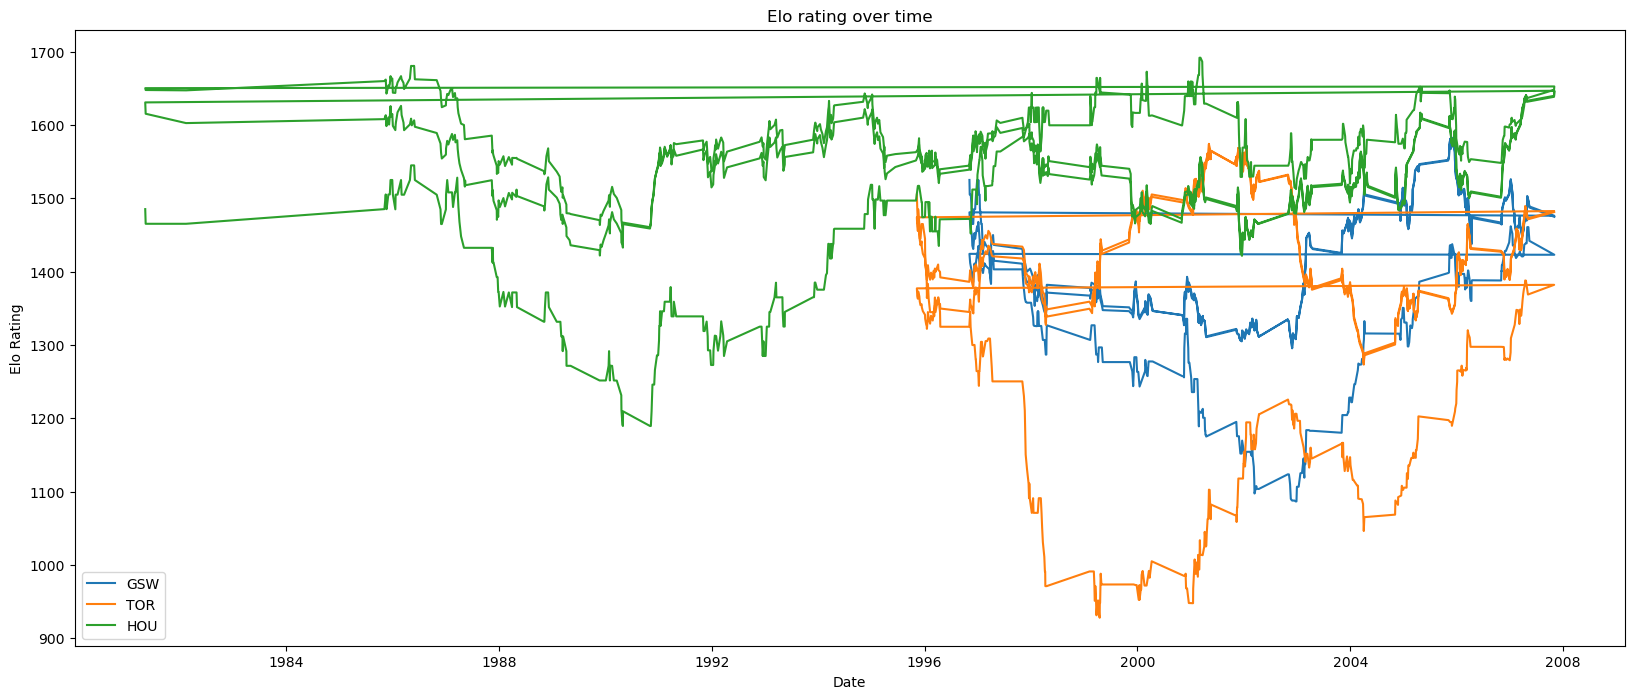

In [ ]:
fig, ax = plt.subplots(figsize=(20, 8))
estimator.plot(['GSW', 'TOR', 'HOU'], ax=ax)
plt.show()

## Evaluate the predictions

In [148]:
y_val_pred = estimator.predict_proba(train_set)[:, 1]
print(f"Test set log-loss: {log_loss(train_set['result'], y_val_pred):.4f}")

Test set log-loss: 0.6363


In [149]:
confusion_matrix(train_set['result'], y_val_pred.round())

array([[11166,  6113],
       [ 6124, 11151]])

### Check the calibration

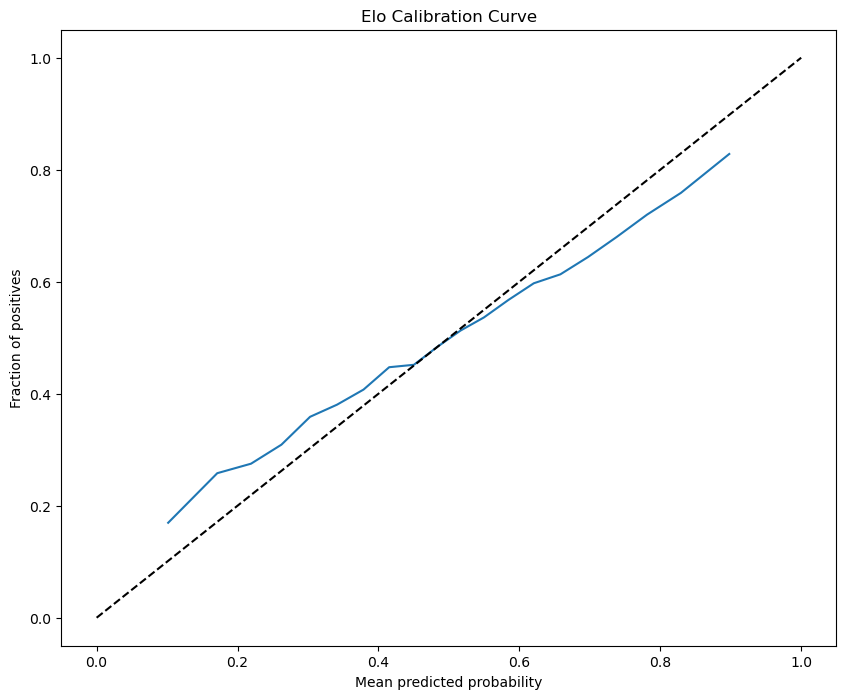

In [150]:
prob_true, prob_pred = calibration_curve(train_set['result'], y_val_pred, n_bins=20, strategy='quantile')

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(prob_pred, prob_true)
ax.plot([0, 1], [0, 1], color='black', linestyle='--')
ax.set(
    title='Elo Calibration Curve',
    xlabel='Mean predicted probability',
    ylabel='Fraction of positives',
)

plt.show()


# The code below is not organized and not all of it works

### Grid search

In [ ]:
estimator = EloEstimator(
    k_factor=20, 
    beta=200,
    default_init_rating=1505,
    entity_cols=("team_abbreviation_main", "team_abbreviation_opp"),
    score_col="result",
    date_col="t",
    track_rating_history=True,
    # Set k-factor/step-size to 1 for the home advantage regressor
    additional_regressors=[Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=0.4) for p in all_predictors]
)

In [25]:
def get_log_loss(df_train, df_test, lambda_):
    model = EloEstimator(
        k_factor=20, 
        beta=200,
        default_init_rating=1505,
        entity_cols=("team_abbreviation_main", "team_abbreviation_opp"),
        score_col="result",
        date_col="t",
        track_rating_history=True,
        additional_regressors=[Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=lambda_) for p in all_predictors]
    )
    #model.fit(df_train)

    # Predict probabilities
    y_val_pred = model.predict_proba(df_train)[:, 1]
    log_loss_result = log_loss(df_test['result'], y_val_pred)

    return log_loss_result

def grid_search_elo_estimator(df, lambda_grid, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = []

    for lambda_ in lambda_grid:
        fold_losses = []

        for train_idx, test_idx in tscv.split(df):
            df_train, df_test = df.iloc[train_idx], df.iloc[test_idx]
            loss = get_log_loss(df_train, df_test, lambda_)
            fold_losses.append(loss)

        avg_loss = np.mean(fold_losses)
        results.append({'lambda': lambda_, 'log_loss': avg_loss})

    return pd.DataFrame(results).sort_values('log_loss')




In [30]:
all_col_names = train_set.columns
train_set_panda = pd.DataFrame(train_set, columns=all_col_names)
train_set_panda['result'] = train_set_panda['result'].astype(int)

In [27]:

# df = pd.read_csv("match_data.csv")
# df = df.sort_values('timestamp')  

lambda_grid = [0.0, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]


In [29]:
train_set_panda.result.unique()

array([1, 0], dtype=object)

In [31]:
result_df = grid_search_elo_estimator(df=train_set_panda, lambda_grid=lambda_grid)
print(result_df)

ValueError: Found input variables with inconsistent numbers of samples: [11518, 5759]

In [213]:
gs = GridSearchCV(
    estimator=SKEloEstimator(entity_cols=('team_abbreviation_main', 'team_abbreviation_opp'), score_col='result'), 
    param_grid={
        'beta': [200],
        'k_factor': [20],
        'additional_regressors': [[Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=0.1) for p in all_predictors],
                                  [Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=0.2) for p in all_predictors],
                                  [Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=0.3) for p in all_predictors],
                                  [Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=0.4) for p in all_predictors],
                                  [Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=0.5) for p in all_predictors],
                                  [Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=0.6) for p in all_predictors],
                                  [Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=0.7) for p in all_predictors],
                                  [Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=0.8) for p in all_predictors],
                                  [Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=0.9) for p in all_predictors],
                                  [Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=1.0) for p in all_predictors],
                                  [Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=2) for p in all_predictors]]
                },
    cv=TimeSeriesSplit(n_splits=5),
)


In [173]:
gs.fit(train_set, train_set['result'])
pl.DataFrame(gs.cv_results_).sort('mean_test_score', descending=False)

ValueError: 
All the 55 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
55 fits failed with the following error:
Traceback (most recent call last):
  File "/Applications/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Applications/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/elo_grad/__init__.py", line 468, in fit
    self._transform(X, return_expected_score=False)
  File "/Applications/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/elo_grad/__init__.py", line 457, in _transform
    rating_deltas[r.name] += next(_rating_deltas)
                             ^^^^^^^^^^^^^^^^^^^^
StopIteration


### Comparing the log loss with and without the regressors

In [ ]:
y_val_pred_home = elo_home.predict_proba(X_val)[:, 1]
print(f"Validation set log-loss: {log_loss(X_val['result'], y_val_pred_home):.4f}")

We can also visualise the home advantage effect over time.



In [ ]:
fig, ax = plt.subplots(figsize=(20, 8))
elo_home.plot(['home'], ax=ax)
plt.show()

Confusion Matrix:
 [[11166  6113]
 [ 6124 11151]]
Accuracy: 0.6459
Precision: 0.6459
Recall: 0.6455
F1-Score: 0.6457
AUC-ROC: 0.6459


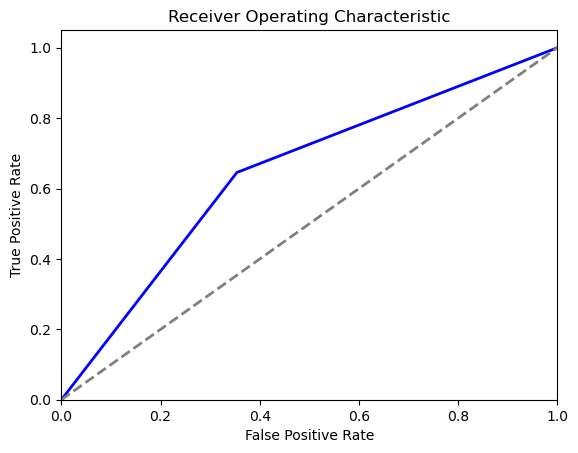

In [168]:
evaluate_model(train_set['result'], y_val_pred.round())

## Mannually doing grid search

In [39]:
# Lambda = 0
# Fit Elo regression
# estimator0 = EloEstimator(
#     k_factor=20, 
#     beta=200,
#     default_init_rating=1505,
#     entity_cols=("team_abbreviation_main", "team_abbreviation_opp"),
#     score_col="result",
#     date_col="t",
#     track_rating_history=True,
#     additional_regressors=[Regressor(name=p, k_factor=1) for p in all_predictors]
# )

gs0 = GridSearchCV(
    estimator=SKEloEstimator(
        default_init_rating=1505,
        entity_cols=('team_abbreviation_main', 'team_abbreviation_main'), 
        score_col='result',
        date_col="t",
        track_rating_history=True,
        additional_regressors=[Regressor(name=p, k_factor=1) for p in all_predictors]), 
    param_grid={
        'beta': [200],
        'k_factor': [20],
    },
    cv=TimeSeriesSplit(n_splits=5),
)
gs0.fit(train_set, train_set['result'])
pl.DataFrame(gs0.cv_results_).sort('mean_test_score', descending=False)

# y_val_pred0 = estimator0.predict_proba(train_set)[:, 1]
# print(f"Test set log-loss: {log_loss(train_set['result'], y_val_pred0):.4f}")

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/Applications/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/narwhals/dataframe.py", line 172, in select
    self._compliant_frame.simple_select(*flat_exprs)
  File "/Applications/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/narwhals/_polars/dataframe.py", line 375, in simple_select
    return self._with_native(self.native.select(*column_names))
                             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Applications/anaconda3/envs/erdos_summer_2025/lib/python3.12/site-packages/polars/dataframe/frame.py", line 9833, in select
    .collect(optimizations=QueryOptFlags._eager())
     ^^^^^^^^^

In [ ]:
# Lambda = 0.01
# Fit Elo regression
estimator_01 = EloEstimator(
    k_factor=20, 
    beta=200,
    default_init_rating=1505,
    entity_cols=("team_abbreviation_main", "team_abbreviation_opp"),
    score_col="result",
    date_col="t",
    track_rating_history=True,
    additional_regressors=[Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=0.01) for p in all_predictors]
)
# # Get expected scores
# expected_scores = estimator.predict_proba(train_set)
# # Get final ratings (of form (timestamp, rating)) for home advantage
# ratings = estimator.model.ratings

y_val_pred_01 = estimator_01.predict_proba(train_set)[:, 1]
print(f"Test set log-loss: {log_loss(train_set['result'], y_val_pred_01):.4f}")

Test set log-loss: 2.8223


In [ ]:
# Lambda = 0.1
# Fit Elo regression
estimator_1 = EloEstimator(
    k_factor=20, 
    beta=200,
    default_init_rating=1505,
    entity_cols=("team_abbreviation_main", "team_abbreviation_opp"),
    score_col="result",
    date_col="t",
    track_rating_history=True,
    additional_regressors=[Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=0.1) for p in all_predictors]
)
# # Get expected scores
# expected_scores = estimator.predict_proba(train_set)
# # Get final ratings (of form (timestamp, rating)) for home advantage
# ratings = estimator.model.ratings

y_val_pred_1 = estimator_1.predict_proba(train_set)[:, 1]
print(f"Test set log-loss: {log_loss(train_set['result'], y_val_pred_1):.4f}")

Test set log-loss: 2.0256


In [35]:
# Lambda = 1
# Fit Elo regression
estimator1 = EloEstimator(
    k_factor=20, 
    beta=200,
    default_init_rating=1505,
    entity_cols=("team_abbreviation_main", "team_abbreviation_opp"),
    score_col="result",
    date_col="t",
    track_rating_history=True,
    additional_regressors=[Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=1) for p in all_predictors]
)
# # Get expected scores
# expected_scores = estimator.predict_proba(train_set)
# # Get final ratings (of form (timestamp, rating)) for home advantage
# ratings = estimator.model.ratings

y_val_pred1 = estimator1.predict_proba(train_set)[:, 1]
print(f"Test set log-loss: {log_loss(train_set['result'], y_val_pred1):.4f}")

Test set log-loss: 0.9342


In [36]:
# Lambda = 10
# Fit Elo regression
estimator10 = EloEstimator(
    k_factor=20, 
    beta=200,
    default_init_rating=1505,
    entity_cols=("team_abbreviation_main", "team_abbreviation_opp"),
    score_col="result",
    date_col="t",
    track_rating_history=True,
    additional_regressors=[Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=10) for p in all_predictors]
)

y_val_pred10 = estimator10.predict_proba(train_set)[:, 1]
print(f"Test set log-loss: {log_loss(train_set['result'], y_val_pred10):.4f}")

Test set log-loss: 0.9329


In [37]:
# Lambda = 100
# Fit Elo regression
estimator100 = EloEstimator(
    k_factor=20, 
    beta=200,
    default_init_rating=1505,
    entity_cols=("team_abbreviation_main", "team_abbreviation_opp"),
    score_col="result",
    date_col="t",
    track_rating_history=True,
    additional_regressors=[Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=100) for p in all_predictors]
)

y_val_pred100 = estimator100.predict_proba(train_set)[:, 1]
print(f"Test set log-loss: {log_loss(train_set['result'], y_val_pred100):.4f}")

Test set log-loss: 5.9593
